In [1]:
! pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# --- Basic Imports ---
from utils import *

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score,
                             precision_recall_fscore_support, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, log_loss)

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from category_encoders import WOEEncoder
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, Booster
import xgboost as xgb
import shap
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.linspace(0.01, 0.99, 200)
    scores = []

    for t in thresholds:
        y_pred = (y_prob > t).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )

        if metric == "precision":
            scores.append(precision)
        elif metric == "recall":
            scores.append(recall)
        else:  # default f1
            scores.append(f1)

    scores = np.array(scores)
    best_idx = scores.argmax()
    best_threshold = thresholds[best_idx]
    best_score = scores[best_idx]

    return best_threshold, best_score, thresholds, scores, metric

In [4]:
# Plot Themes
ACCENT_COLOR = "#2ab7ca"
SECOND_COLOR = "#0d3b66"
HIGHLIGHT_COLOR = "#ff0000ea"

# --- Theme & custom accent color ---
sns.set_theme(style="whitegrid", palette="mako")

model_type = 'XGBoost_Model'
start_date = dt.datetime.now().strftime('%Y%m%d_%H%M%S')
timestamp = dt.datetime.strptime(start_date, '%Y%m%d_%H%M%S').strftime("%Y-%m-%d %H:%M:%S")
path = MODEL_DIR+model_type+"_"+start_date

os.makedirs(path, exist_ok=True)

In [5]:
df = pd.read_csv(os.path.join(SILVER_PATH, 'base_dataset.csv'), sep=';')

# Feature Engineering

In [6]:
# Show job categories from dataset
job_counts = df['job'].value_counts(normalize=True)
print(job_counts)

# Map jobs to categories to reduce cardinality
job_mapping = {
    "admin.": "admin",
    "blue-collar": "blue_collar",
    "technician": "technician",
    "services": "services_group",
    "housemaid": "services_group",
    "management": "management",
    "retired": "no_labor_force",
    "student": "no_labor_force",
    "unemployed": "no_labor_force",
    "entrepreneur": "self_employed_group",
    "self-employed": "self_employed_group",
    "unknown": "unknown"
}
df['job'] = df['job'].map(job_mapping)

job
admin.           0.253036
blue-collar      0.224718
technician       0.163663
services         0.096343
management       0.071012
retired          0.041723
entrepreneur     0.035360
self-employed    0.034510
housemaid        0.025743
unemployed       0.024626
student          0.021250
unknown          0.008014
Name: proportion, dtype: float64


In [7]:
# Show education categories from dataset
education_counts = df['education'].value_counts(normalize=True)
print(education_counts)

# ------------------------------------------
# Education Simplification Mapping (Dictionary)
# ------------------------------------------
education_map = {
    "university.degree": "university_degree",
    "high.school": "high_school",
    "basic.9y": "basic_education",
    "basic.6y": "basic_education",
    "basic.4y": "basic_education",
    "illiterate": "illiterate",
    "professional.course": "professional_course",
    "unknown": "unknown"
}

# Apply mapping
df["education_simplified"] = df["education"].map(education_map).fillna("unknown")


education
university.degree      0.295415
high.school            0.231008
basic.9y               0.146809
professional.course    0.127259
basic.4y               0.101418
basic.6y               0.055639
unknown                0.042015
illiterate             0.000437
Name: proportion, dtype: float64


In [8]:
# Cyclical encoding of 'month' feature and day-of-the-week feature
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop('month', axis=1, inplace=True)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df.drop('day_of_week', axis=1, inplace=True)

In [9]:
# Numeric × Numeric
df["age_emp_rate"] = df["age"] * df["emp_var_rate"]
df["cons_price_cons_conf"] = df["cons_price_idx"] * df["cons_conf_idx"]
df["euribor_nrm"] = df["euribor3m"] / (df["nr_employed"] + 1)

# Categorical × Numeric
df["job_x_age"] = df["job"].astype(str) + "_" + pd.cut(df["age"], bins=[18,30,45,60,100]).astype(str)

# Categorical × Categorical
df["job_x_marital"] = df["job"].astype(str) + "_" + df["marital"].astype(str)
df["education_x_default"] = df["education"].astype(str) + "_" + df["default"].astype(str)

# Campaign intensity
df["campaign_log"] = np.log1p(df["campaign"])
df["contacts_ratio"] = df["campaign"] / (df["pdays"] + 2)

# Volatility indicators
df["economic_volatility"] = df[["cons_price_idx","cons_conf_idx","emp_var_rate"]].std(axis=1)

df.to_csv(os.path.join(SILVER_PATH, 'base_dataset_XGB_Engineered.csv'), sep=";", index=False)

# XGBoost

### Train Test Split

In [10]:
X = df.drop(columns=['y']).copy()
y = df['y'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### PCA on
- `emp_var_rate`  
- `euribor3m`  
- `nr_employed`  
- `cons_price_idx`  

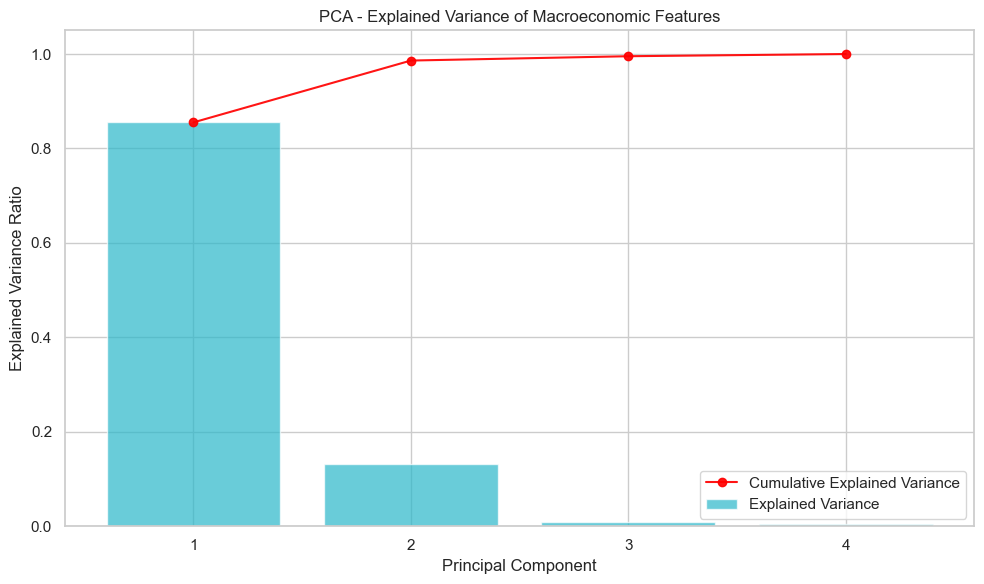

In [11]:
macro_cols = ['emp_var_rate','euribor3m','nr_employed','cons_price_idx']

# Extract macroeconomic features from training data
X_macro_train = X_train[macro_cols].copy()
X_macro_test = X_test[macro_cols].copy()

# Standardize the macroeconomic features
scaler = StandardScaler()
X_macro_train_scaled = scaler.fit_transform(X_macro_train)
X_macro_test_scaled = scaler.transform(X_macro_test)

# Apply PCA to reduce dimensions
pca = PCA()
pca.fit(X_macro_train_scaled)

# Explained variance ratios
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
plt.figure(figsize=(10,6))

components = np.arange(1, len(explained_var) + 1)

# Bar plot for individual component variance
plt.bar(components, explained_var, alpha=0.7, label="Explained Variance", color=ACCENT_COLOR)

# Line plot for cumulative variance
plt.plot(components, cumulative_var, marker='o', color=HIGHLIGHT_COLOR, label="Cumulative Explained Variance")

plt.xticks(components)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA - Explained Variance of Macroeconomic Features")
plt.legend()
plt.tight_layout()
plt.savefig(f"{path}/pca_explained_variance.png", dpi=300)
plt.show()

Keeping 2 principal componenets to explain more than 85% of the variance of the 4 features we will apply PCA to 1 component removing the 4 features

### Fit pipeline

In [12]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features

(['age',
  'campaign',
  'pdays',
  'previous',
  'emp_var_rate',
  'cons_price_idx',
  'cons_conf_idx',
  'euribor3m',
  'nr_employed',
  'month_sin',
  'month_cos',
  'day_of_week_sin',
  'day_of_week_cos',
  'age_emp_rate',
  'cons_price_cons_conf',
  'euribor_nrm',
  'campaign_log',
  'contacts_ratio',
  'economic_volatility'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'poutcome',
  'education_simplified',
  'job_x_age',
  'job_x_marital',
  'education_x_default'])

In [13]:
# Search space for hyperparameter tuning
param_grid = {
    "preprocessor__num__select__k": [5, 10],
    "preprocessor__cat__woe__regularization": [0.1, 10.0],
    "preprocessor__cat__select__k": [4, 7],
    "smote__sampling_strategy": [0.5, 0.7],
    "smote__k_neighbors": [3, 5],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__n_estimators": [200, 400],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.7, 1.0],
    "model__min_child_weight": [1, 5]
}

In [14]:
def replace_unknowns(df):
    return df.replace("unknown", np.nan)

In [15]:
# Preprocessing pipelines for numeric and categorical data
pca_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

numeric_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif))
])

categorical_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("woe", WOEEncoder(handle_missing="value", handle_unknown="value")),
    ("select", SelectKBest(score_func=mutual_info_classif))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("macro_economics", pca_pipeline, macro_cols),
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop"
)

cleaner = FunctionTransformer(replace_unknowns, validate=False, feature_names_out="one-to-one")

# # SMOTE approach
clf = Pipeline(steps=[
    ("clean", cleaner),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=42
    ))
])

# Grid Search for Hyperparameter Tuning
grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=3
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best ROC AUC:", grid.best_score_)

# Replace clf with best pipeline
clf = grid.best_estimator_

Fitting 3 folds for each of 3072 candidates, totalling 9216 fits
Best parameters: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 200, 'model__subsample': 0.8, 'preprocessor__cat__select__k': 4, 'preprocessor__cat__woe__regularization': 10.0, 'preprocessor__num__select__k': 5, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.7}
Best ROC AUC: 0.7962291962574847


In [16]:
for i, err in enumerate(grid.cv_results_["std_test_score"]):
    if np.isnan(err):
        print("Candidate", i, "failed.")

In [17]:
# Access fitted preprocessor
pre = clf.named_steps["preprocessor"]

# Automatically get correct feature names
final_feature_names = pre.get_feature_names_out()

print("Final feature names:", final_feature_names)
print("Feature count:", len(final_feature_names))

# XGBoost feature importances
importances = clf.named_steps["model"].feature_importances_

print("Importance count:", len(importances))

feature_importance = pd.DataFrame({
    "feature": final_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance)

Final feature names: ['macro_economics__pca0' 'macro_economics__pca1' 'num__pdays'
 'num__emp_var_rate' 'num__euribor3m' 'num__nr_employed'
 'num__euribor_nrm' 'cat__0' 'cat__6' 'cat__7' 'cat__9']
Feature count: 11
Importance count: 11
                  feature  importance
5        num__nr_employed    0.588969
3       num__emp_var_rate    0.135305
2              num__pdays    0.059572
4          num__euribor3m    0.053872
0   macro_economics__pca0    0.040342
1   macro_economics__pca1    0.029092
9                  cat__7    0.024179
6        num__euribor_nrm    0.021492
8                  cat__6    0.018300
7                  cat__0    0.015387
10                 cat__9    0.013490


### Threshold Tunning

📌 Best threshold: 0.5320100502512564
📈 Best F1 score: 0.5071469411092052
ROC AUC: 0.8064986831802975


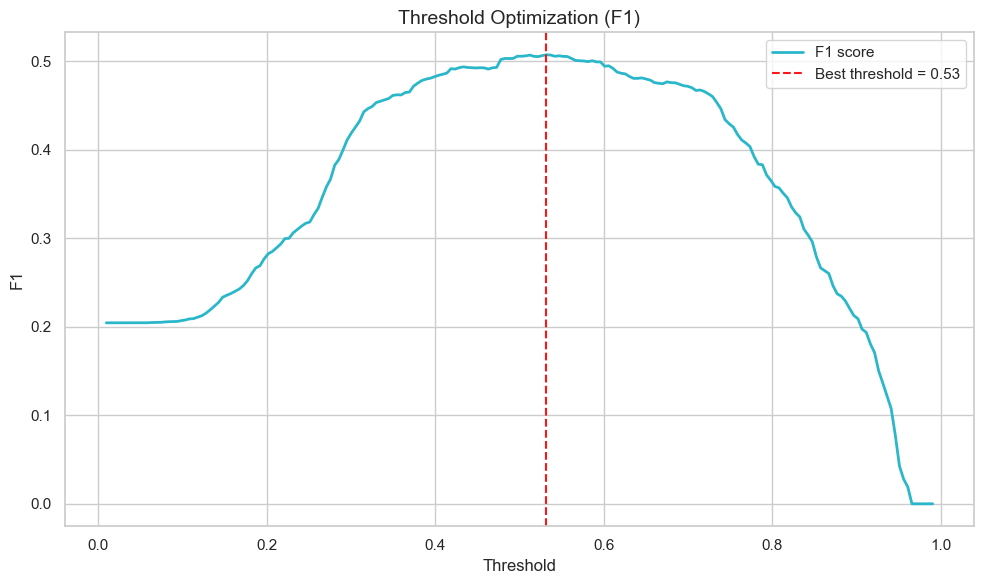


Classification Report with Best Threshold:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     12042
           1       0.45      0.57      0.51      1547

    accuracy                           0.87     13589
   macro avg       0.70      0.74      0.72     13589
weighted avg       0.89      0.87      0.88     13589

Confusion Matrix:
[[10978  1064]
 [  660   887]]


In [18]:
sns.set(style="whitegrid")

# Run optimization
y_prob = clf.predict_proba(X_test)[:, 1]

best_threshold, best_score, thresholds, scores, metric = find_best_threshold(
    y_test, y_prob, metric="f1"
)

print("📌 Best threshold:", best_threshold)
print("📈 Best F1 score:", best_score)
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# Seaborn plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=thresholds, y=scores, label=f"{metric.upper()} score", linewidth=2, color=ACCENT_COLOR)

plt.axvline(best_threshold, color=HIGHLIGHT_COLOR, linestyle='--',
            label=f"Best threshold = {best_threshold:.2f}")

plt.xlabel("Threshold", fontsize=12)
plt.ylabel(metric.upper(), fontsize=12)
plt.title(f"Threshold Optimization ({metric.upper()})", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(f"{path}/threshold_optimization.png", dpi=300)
plt.show()

# Apply best threshold
y_pred_opt = (y_prob > best_threshold).astype(int)

print("\nClassification Report with Best Threshold:")
print(classification_report(y_test, y_pred_opt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_opt))


**Model Performance Analysis**


### Least useful features

In [19]:
xgb_model = clf.named_steps["model"]
importances = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": final_feature_names,
    "importance": importances,
    "abs_importance": np.abs(importances)
}).sort_values("abs_importance", ascending=False)

print(feature_importance)

# Features with very low importance (e.g., < 0.01)
cols_to_drop = feature_importance[feature_importance["abs_importance"] <= 0.01]["feature"].tolist()
print(feature_importance[feature_importance["abs_importance"] <= 0.01])

                  feature  importance  abs_importance
5        num__nr_employed    0.588969        0.588969
3       num__emp_var_rate    0.135305        0.135305
2              num__pdays    0.059572        0.059572
4          num__euribor3m    0.053872        0.053872
0   macro_economics__pca0    0.040342        0.040342
1   macro_economics__pca1    0.029092        0.029092
9                  cat__7    0.024179        0.024179
6        num__euribor_nrm    0.021492        0.021492
8                  cat__6    0.018300        0.018300
7                  cat__0    0.015387        0.015387
10                 cat__9    0.013490        0.013490
Empty DataFrame
Columns: [feature, importance, abs_importance]
Index: []


### SHAP

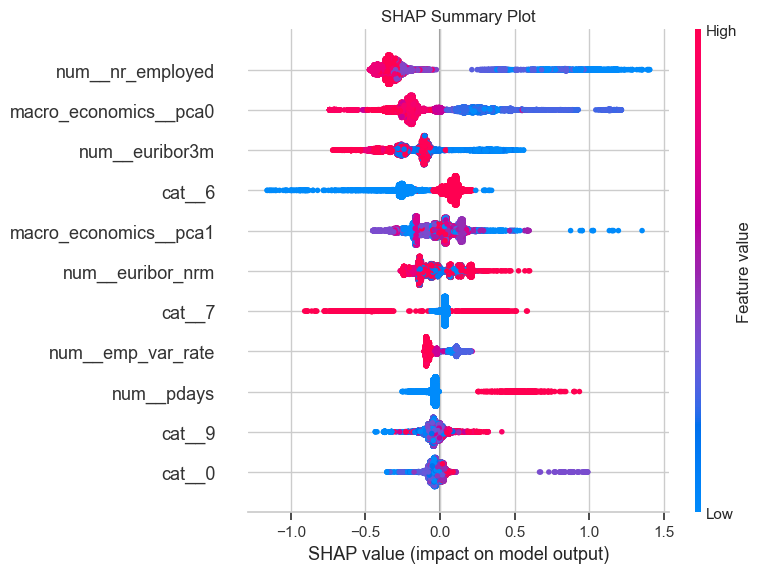

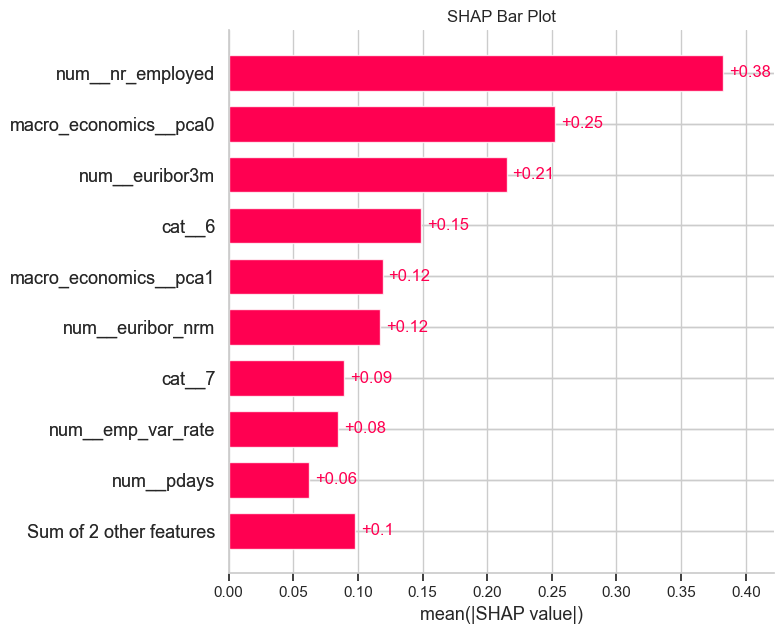

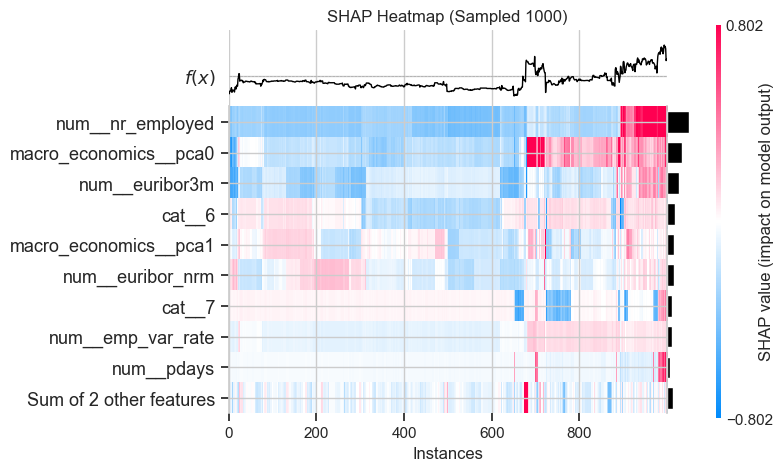

In [20]:
model = clf.named_steps["model"]
preprocessor = clf.named_steps["preprocessor"]

# Transform
X_test_transformed = preprocessor.transform(X_test)

# Convert feature names to list (not numpy array!)
feature_names = preprocessor.get_feature_names_out().tolist()

# Convert to DMatrix
dm = xgb.DMatrix(
    X_test_transformed,
    feature_names=feature_names
)

# Get SHAP-like values directly from XGBoost
shap_values = model.get_booster().predict(dm, pred_contribs=True)

# Base values are the last column
base_values = shap_values[:, -1]

# Remove last column (bias term)
shap_values = shap_values[:, :-1]

# Build SHAP explanation object
import shap

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_test_transformed,
    feature_names=feature_names
)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_exp, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig(f"{path}/summary_plot.png", dpi=300)
plt.show()

# Bar Plot
plt.figure(figsize=(9, 6))
shap.plots.bar(shap_exp, show=False)
plt.title("SHAP Bar Plot")
plt.tight_layout()
plt.savefig(f"{path}/bar_plot.png", dpi=300)
plt.show()

# Heatmap Plot (sampled)
idx = np.random.choice(len(shap_exp), size=1000, replace=False)
shap_exp_sampled = shap_exp[idx]

plt.figure(figsize=(12, 6))
shap.plots.heatmap(shap_exp_sampled, show=False)
plt.title("SHAP Heatmap (Sampled 1000)")
plt.tight_layout()
plt.savefig(f"{path}/heatmap_plot.png", dpi=300)
plt.show()


# Metrics storage and model on gold

In [21]:
# Predict probabilities and classes
proba = clf.predict_proba(X_test)

# Some XGBoost versions return shape (n, 1) — fix it:
if proba.shape[1] == 1:
    y_pred_proba = proba[:, 0]
else:
    y_pred_proba = proba[:, 1]

y_pred = (y_pred_proba >= best_threshold).astype(int)

best_parameters = grid.best_params_

# Metrics dictionary
metrics = {
    "AUC": roc_auc_score(y_test, y_pred_proba),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "LogLoss": log_loss(y_test, y_pred_proba),
    "Best Threshold": best_threshold,
    "Best Parameters": best_parameters,
    "Feature Names": final_feature_names
}

# Save metrics for XGBoost
save_metrics(model_type + "_" + start_date, "XGBoost", metrics, timestamp)
save_metrics(model_type, "XGBoost", metrics, timestamp)


Metrics saved for XGBoost → ../97-model_metrics/XGBoost_Model_20251201_181913/XGBoost_metrics.csv
Metrics saved for XGBoost → ../97-model_metrics/XGBoost_Model/XGBoost_metrics.csv


In [22]:
model = ModelWrapper(
    pipeline=clf,
    threshold=best_threshold,
    metadata={
        "model_type": "XGBoost",
        "AUC": metrics["AUC"],
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1": metrics["F1"],
        "LogLoss": metrics["LogLoss"],
        "notes": "SMOTE + WOE, PCA for macro features, feature selection, cleaning unknowns and imputation",
        "Feature Names": final_feature_names,
        "Confusion Matrix": confusion_matrix(y_test, y_pred_opt),
        "Classification Report": classification_report(y_test, y_pred_opt)
    }
)

model.save(GOLD_PATH + f"/XGBoost_Model_{start_date}.pkl")

Model saved to ../01-data/03-gold//XGBoost_Model_20251201_181913.pkl
